In [ ]:
import pdfplumber
import pandas as pd

data = []

with pdfplumber.open("fitness_dataset-1.pdf") as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        for row in table[1:]:  # skip header
            data.append(row)

# Create DataFrame
columns = ["Date", "Steps", "Calories", "Protein", "Water", "Weight", "Exercise"]
df = pd.DataFrame(data, columns=columns)

print(df.head())

    Date Steps Calories Protein Water Weight Exercise
0  01-01  5000     1800      55   2.5     65       30
1  02-01  7000     1700      60     3   64.8       40
2  03-01  6000     1750      58   2.8   64.7       35
3  04-01  8000     1650      62   3.2   64.5       45
4  05-01  7500     1680      61     3   64.3       40


In [ ]:
df['Steps']=df['Steps'].astype(int)
df['Calories']=df['Calories'].astype(int)
df['Protein']=df['Protein'].astype(int)
df['Water']=df['Water'].astype(float)
df['Weight']=df['Weight'].astype(float)
df['Exercise']=df['Exercise'].astype(int)
df['Date']=pd.to_datetime(df['Date'],format="%d-%m-%y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      25 non-null     datetime64[ns]
 1   Steps     25 non-null     int64         
 2   Calories  25 non-null     int64         
 3   Protein   25 non-null     int64         
 4   Water     25 non-null     float64       
 5   Weight    25 non-null     float64       
 6   Exercise  25 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 1.5 KB


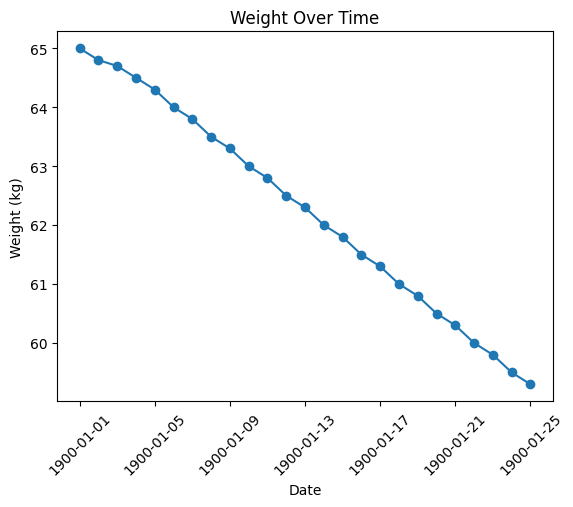

In [ ]:
#weight trend
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df['Date'],df['Weight'],marker='o')
plt.title("Weight Over Time")
plt.xlabel("Date")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=45)
plt.show()


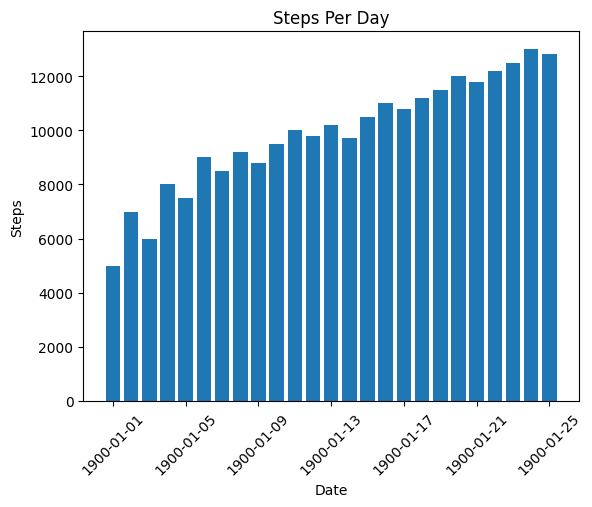

In [ ]:
#STEPS PER DAY
plt.figure()
plt.bar(df['Date'],df['Steps'])
plt.title("Steps Per Day")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.xticks(rotation=45)
plt.show()

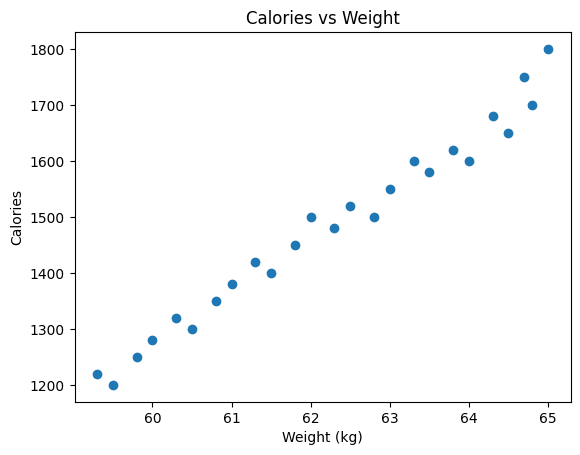

In [20]:
#Calories vs Weight
plt.figure()
plt.scatter(df['Weight'],df['Calories'])
plt.title("Calories vs Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Calories")
plt.show()

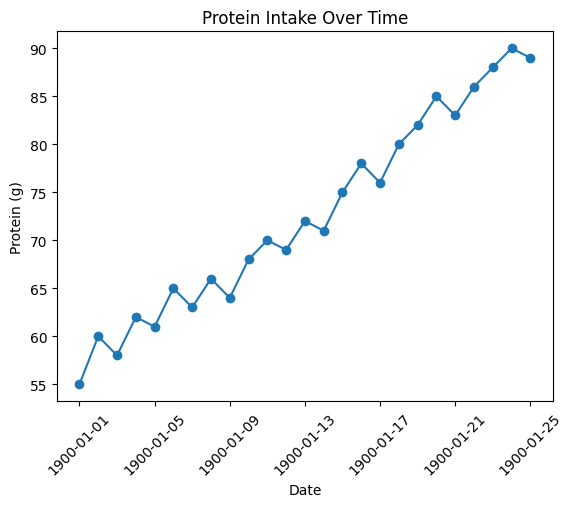

In [21]:
#Protein intake
plt.figure()
plt.plot(df['Date'],df['Protein'],marker='o')
plt.title("Protein Intake Over Time")
plt.xlabel("Date")
plt.ylabel("Protein (g)")
plt.xticks(rotation=45)
plt.show()

In [24]:
print("Average steps:",df['Steps'].mean())
print("Average calories:",df['Calories'].mean())
print("Average protein:",df['Protein'].mean())
print("Average weight:",df['Weight'].mean())
print("Weight Change:",
df["Weight"].iloc[0]-
df["Weight"].iloc[-1])

Average steps: 9900.0
Average calories: 1484.0
Average protein: 72.64
Average weight: 62.251999999999995
Weight Change: 5.700000000000003
